# install

In [3]:
! pip install lightning
! pip install torchview
! pip install torchmetrics

# import

In [4]:
# ===============================
# PyTorch Core Modules
# ===============================
import torch  # Core tensor operations
from torch import Tensor
import torch.nn as nn  # Neural network layers
import torch.nn.functional as F  # Functional API for activations, losses, etc.
import torch.optim as optim  # Optimizers
from torch.utils.data import Dataset, DataLoader, random_split  # Dataset utilities

# ===============================
# PyTorch Ecosystem
# ===============================
import pytorch_lightning as pl  # High-level training framework
import torchmetrics  # Model evaluation metrics
from torchview import draw_graph  # Model visualization
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor # Callbacks

# ===============================
# TorchVision - For image data
# ===============================
import torchvision  # Pretrained models and datasets
import torchvision.transforms as transforms  # Image preprocessing utilities
import torchvision.models as models
from torchvision.io import read_image, decode_image
from torchvision.models import resnet50, ResNet50_Weights, MobileNet_V3_Large_Weights

# ===============================
# Scikit-learn - Data generation and preprocessing
# ===============================
from sklearn.datasets import make_regression  # Synthetic regression data
from sklearn.model_selection import train_test_split  # Train/test splitting
from sklearn.preprocessing import MinMaxScaler  # Feature scaling

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt  # Plotting utilities

# ===============================
# Numerical Computing
# ===============================
import numpy as np  # Array operations
import math  # Basic mathematical functions

from PIL import Image
import requests
import io
import json

import os

# Dataset

## Load

In [5]:
import kagglehub

path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")

print("Path to dataset files:", path)
# %ls -R {path}

Path to dataset files: /root/.cache/kagglehub/datasets/yudhaislamisulistya/plants-type-datasets/versions/16


## PlantDataset


In [6]:
from torchvision.io import read_image

class PlantDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = []
        self.labels = []
        self.class_to_idx = {}
        idx = 0
        for class_name in os.listdir(root_dir):
            class_dir = os.path.join(root_dir, class_name)
            if os.path.isdir(class_dir):
                self.class_to_idx[class_name] = idx
                for image_file in os.listdir(class_dir):
                    if image_file.endswith('.jpg') or image_file.endswith('.png'):
                        self.image_files.append(os.path.join(class_dir, image_file))
                        self.labels.append(idx)
                idx += 1

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = self.image_files[idx]
        image = read_image(img_path).float() / 255.0 # Read as float and scale to [0, 1]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## transforms



In [7]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    # transforms.ToTensor(), # Remove ToTensor as read_image already returns a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((32, 32)), # Changed from 128x128 to 32x32
    # transforms.ToTensor(), # Remove ToTensor as read_image already returns a tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((32, 32)), # Changed from
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## DataLoader


In [8]:
train_root_dir = f'{path}/split_ttv_dataset_type_of_plants/Train_Set_Folder'
val_root_dir = f'{path}/split_ttv_dataset_type_of_plants/Validation_Set_Folder'
test_root_dir = f'{path}/split_ttv_dataset_type_of_plants/Test_Set_Folder'

train_dataset = PlantDataset(root_dir=train_root_dir, transform=train_transforms)
val_dataset = PlantDataset(root_dir=val_root_dir, transform=val_transforms)
test_dataset = PlantDataset(root_dir=test_root_dir, transform=test_transforms)

batch_size = 64

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of batches in training DataLoader: {len(train_dataloader)}")
print(f"Number of batches in validation DataLoader: {len(val_dataloader)}")
print(f"Number of batches in test DataLoader: {len(test_dataloader)}")

Number of batches in training DataLoader: 375
Number of batches in validation DataLoader: 48
Number of batches in test DataLoader: 47


# Custom CNN

## simple cnn

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

class SimpleCNN_TF(models.Model):
    def __init__(self, num_classes):
        super(SimpleCNN_TF, self).__init__()
        self.conv1 = layers.Conv2D(32, (3, 3), padding='same', activation='relu')
        self.maxpool1 = layers.MaxPooling2D((2, 2), strides=(2, 2))

        self.conv2 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.maxpool2 = layers.MaxPooling2D((2, 2), strides=(2, 2))

        self.flatten = layers.Flatten()
        self.fc1 = layers.Dense(128, activation='relu')
        self.fc2 = layers.Dense(num_classes, activation='softmax') # Softmax for classification

    def call(self, x):
        x = self.conv1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.maxpool2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

# Instantiate the TensorFlow CNN model
# Assuming num_classes is already defined from the dataset loading
tf_cnn_model = SimpleCNN_TF(num_classes=num_classes)

# Build the model with a dummy input shape to see the summary
# Assuming input images are 32x32 with 3 channels, similar to your PyTorch model
dummy_input_tf = tf.random.uniform((1, 32, 32, 3))
tf_cnn_model.build(input_shape=(None, 32, 32, 3)) # Batch size can be None

print("Simple CNN Model defined (TensorFlow):")
tf_cnn_model.summary()

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # First convolutional layer
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 3 input channels, 32 output channels, 3x3 kernel
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2) # 2x2 max pooling with stride 2

        # Second convolutional layer
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32 input channels, 64 output channels
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2) # 2x2 max pooling with stride 2

        # # Third convolutional layer
        # self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 64 input channels, 128 output channels
        # self.relu3 = nn.ReLU()
        # self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=3) # 3x3 max pooling with stride 3

        # Fully connected layers
        # The size of the input to the first fully connected layer depends on the output of the convolutional layers
        # For 32x32 images, after two conv/pool layers (kernel=2, stride=2):
        # After conv1 (3x3, p=1): size remains 32x32
        # After maxpool1 (k=2, s=2): Output size = floor((Input Size - Kernel Size) / Stride) + 1
        # Height: floor((32 - 2) / 2) + 1 = floor(30 / 2) + 1 = 15 + 1 = 16
        # Width: floor((32 - 2) / 2) + 1 = floor(30 / 2) + 1 = 15 + 1 = 16
        # Size after maxpool1 is 16x16
        # After conv2 (3x3, p=1): size remains 16x16
        # After maxpool2 (k=2, s=2): Output size = floor((Input Size - Kernel Size) / Stride) + 1
        # Height: floor((16 - 2) / 2) + 1 = floor(14 / 2) + 1 = 7 + 1 = 8
        # Width: floor((16 - 2) / 2) + 1 = floor(14 / 2) + 1 = 7 + 1 = 8
        # Size after maxpool2 is 8x8
        self.fc1 = nn.Linear(64 * 8 * 8, 128) # 64 channels * 8x8 spatial dimensions
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes) # Output layer with num_classes for classification

    def forward(self, x):
        # Apply first convolutional block
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.maxpool1(x)

        # Apply second convolutional block
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.maxpool2(x)

        # # Apply third convolutional block
        # x = self.conv3(x)
        # x = self.relu3(x)
        # x = self.maxpool3(x)


        # Flatten the tensor for the fully connected layers
        x = torch.flatten(x, 1) # Flatten starting from dimension 1 (batch dimension is 0)

        # Apply fully connected layers
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.fc2(x)

        return x

# Instantiate the CNN model
num_classes = len(train_dataset.class_to_idx)
cnn_model = SimpleCNN(num_classes=num_classes)

print("Simple CNN Model defined:")
print(cnn_model)

Simple CNN Model defined:
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (relu4): ReLU()
  (fc2): Linear(in_features=128, out_features=30, bias=True)
)


## wrapper

In [ ]:
import tensorflow as tf
import pytorch_lightning as pl
import torchmetrics

class TFPlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters() # Saves hyperparameters
        self.model = SimpleCNN_TF(num_classes) # Instantiate the TensorFlow model

        self.criterion = tf.keras.losses.CategoricalCrossentropy() # Loss function for classification
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes) # Metric for accuracy

    def forward(self, x):
        # PyTorch Lightning expects a tensor, so convert TensorFlow output to tensor
        return torch.tensor(self.model(x).numpy())


    def training_step(self, batch, batch_idx):
        images, labels = batch
        # Convert PyTorch tensors to TensorFlow tensors
        images_tf = tf.convert_to_tensor(images.permute(0, 2, 3, 1).numpy()) # Convert from (B, C, H, W) to (B, H, W, C)
        labels_tf = tf.convert_to_tensor(labels.numpy())

        with tf.GradientTape() as tape:
            outputs = self.model(images_tf)
            # Convert labels to one-hot encoding for CategoricalCrossentropy
            labels_one_hot = tf.one_hot(labels_tf, depth=self.hparams.num_classes)
            loss = self.criterion(labels_one_hot, outputs)

        # Apply gradients manually since we are using a TF model in a PL module
        optimizer = self.optimizers()
        gradients = tape.gradient(loss, self.model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))


        self.log('train_loss', loss.numpy()) # Log TensorFlow loss
        # Convert TensorFlow outputs and labels back to PyTorch tensors for torchmetrics
        self.log('train_acc', self.accuracy(torch.tensor(outputs.numpy()), labels))
        return loss.numpy()

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        # Convert PyTorch tensors to TensorFlow tensors
        images_tf = tf.convert_to_tensor(images.permute(0, 2, 3, 1).numpy()) # Convert from (B, C, H, W) to (B, H, W, C)
        labels_tf = tf.convert_to_tensor(labels.numpy())

        outputs = self.model(images_tf)
        labels_one_hot = tf.one_hot(labels_tf, depth=self.hparams.num_classes)
        loss = self.criterion(labels_one_hot, outputs)


        self.log('val_loss', loss.numpy()) # Log TensorFlow loss
        # Convert TensorFlow outputs and labels back to PyTorch tensors for torchmetrics
        self.log('val_acc', self.accuracy(torch.tensor(outputs.numpy()), labels))
        return loss.numpy()

    def test_step(self, batch, batch_idx):
        images, labels = batch
        # Convert PyTorch tensors to TensorFlow tensors
        images_tf = tf.convert_to_tensor(images.permute(0, 2, 3, 1).numpy()) # Convert from (B, C, H, W) to (B, H, W, C)
        labels_tf = tf.convert_to_tensor(labels.numpy())

        outputs = self.model(images_tf)
        labels_one_hot = tf.one_hot(labels_tf, depth=self.hparams.num_classes)
        loss = self.criterion(labels_one_hot, outputs)

        self.log('test_loss', loss.numpy()) # Log TensorFlow loss
        # Convert TensorFlow outputs and labels back to PyTorch tensors for torchmetrics
        self.log('test_acc', self.accuracy(torch.tensor(outputs.numpy()), labels))
        return loss.numpy()


    def configure_optimizers(self):
        # Use a TensorFlow optimizer
        optimizer = tf.keras.optimizers.Adam(learning_rate=self.hparams.learning_rate)
        return optimizer

# Instantiate the Lightning Module with the TensorFlow model
num_classes = len(train_dataset.class_to_idx)
tf_lightning_model = TFPlantClassifierLightningModule(num_classes=num_classes)

print("TensorFlow Plant Classifier Lightning Module defined.")
print(tf_lightning_model)

In [ ]:
class PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters() # Saves hyperparameters like num_classes and learning_rate
        self.model = SimpleCNN(num_classes) # Our CNN model
        self.criterion = nn.CrossEntropyLoss() # Loss function for classification
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes) # Metric for accuracy

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss)
        self.log('train_acc', self.accuracy(outputs, labels))
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss)
        self.log('val_acc', self.accuracy(outputs, labels))
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return optimizer

# Instantiate the Lightning Module
num_classes = len(train_dataset.class_to_idx)
lightning_model = PlantClassifierLightningModule(num_classes=num_classes)

print("Plant Classifier Lightning Module defined.")
print(lightning_model)


Plant Classifier Lightning Module defined.
PlantClassifierLightningModule(
  (model): SimpleCNN(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu1): ReLU()
    (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu2): ReLU()
    (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (fc1): Linear(in_features=4096, out_features=128, bias=True)
    (relu4): ReLU()
    (fc2): Linear(in_features=128, out_features=30, bias=True)
  )
  (criterion): CrossEntropyLoss()
  (accuracy): MulticlassAccuracy()
)


## model graph

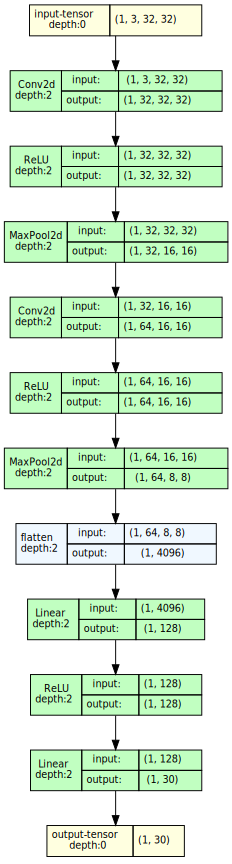

In [ ]:
# Instantiate the Lightning Module
# We need to provide the same parameters as when it was defined
# num_classes = len(train_dataset.class_to_idx)
# lightning_model_for_graph = PlantClassifierLightningModule(num_classes=num_classes)

# # Create a dummy input tensor for PlantDataset images (224x224)
# dummy_input_plant = torch.randn(1, 3, 32, 32)

# # Use draw_graph to visualize the PlantClassifierLightningModule
# plant_model_graph = draw_graph(
#     model=lightning_model_for_graph,
#     input_data=dummy_input_plant,
#     graph_name='Plant Dataset Lightning Module Visualization', # Name for the generated graph
#     # Set depth to a higher value if you want to see more nested modules
#     depth=3 # Adjust this to see more or less detail of the nested SimpleCNN
# )

# # Display the visual graph
# plant_model_graph.visual_graph

## train

In [ ]:
# Model Checkpoint Callback
# Saves the model's weights based on a monitored metric (e.g., validation accuracy)
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc', # Metric to monitor
    mode='max',        # 'max' means we want to maximize the monitored metric
    dirpath='checkpoints/', # Directory to save checkpoints
    filename='best-plant-model', # Name for the checkpoint file
    save_top_k=1,      # Save only the best model based on the monitored metric
    verbose=True       # Print a message when a checkpoint is saved
)

# Early Stopping Callback
# Stops training early if the mbaonitored metric doesn't improve for a certain number of epochs
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Metric to monitor
    mode='min',         # 'min' means we want to minimize the monitored metric
    patience=3,         # Number of epochs with no improvement after which training will be stopped
    verbose=True        # Print a message when early stopping is triggered
)

# Learning Rate Monitor Callback
# Logs the learning rate during training. Useful for learning rate scheduling.
lr_monitor_callback = LearningRateMonitor(logging_interval='step') # Log learning rate at each step

# Instantiate the PyTorch Lightning Trainer
# You can configure various options here, e.g., gpus, max_epochs, etc.
trainer = pl.Trainer(
    max_epochs=10, # Train for a few more epochs to see callbacks in action
    accelerator='auto', # Use GPU if available, otherwise CPU
    devices=1,  # Use 1 device (GPU or CPU)
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback] # Pass the list of callbacks to the Trainer
)

# Start Training
print("Starting Plant Dataset training with callbacks...")
trainer.fit(tf_lightning_model, train_dataloader, val_dataloader)

# Test the model after training
print("\nStarting Plant Dataset testing...")

# For simplicity here, we just test the model in its final state after training
trainer.test(tf_lightning_model, test_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | SimpleCNN          | 547 K  | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | accuracy  | MulticlassAccuracy | 0      | train
---------------------------------------------------------
547 K     Trainable params
0         Non-trainable params
547 K     Total params
2.191     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Starting Plant Dataset training with callbacks...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:Epoch 9, global step 3750: 'val_acc' was not in top 1
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Starting Plant Dataset testing...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.6377584934234619     │
│         test_loss         │    1.0929358005523682     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 1.0929358005523682, 'test_acc': 0.6377584934234619}]

# resnet50

## wrapper

In [ ]:
class ResNetPlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters() # Saves hyperparameters like num_classes and learning_rate
        weights = ResNet50_Weights.DEFAULT
        self.model = resnet50(weights=weights)
        # replace final layer
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss() # Loss function for classification
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes) # Metric for accuracy
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss)
        self.log('train_acc', self.accuracy(outputs, labels))
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss)
        self.log('val_acc', self.accuracy(outputs, labels))
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self.model(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        return loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return optimizer

# Instantiate the Lightning Module
num_classes = len(train_dataset.class_to_idx)
lightning_model = ResNetPlantClassifierLightningModule(num_classes=num_classes)

print("Plant Classifier Lightning Module defined.")
print(lightning_model)


Plant Classifier Lightning Module defined.
ResNetPlantClassifierLightningModule(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (

## train

In [ ]:
# Model Checkpoint Callback
# Saves the model's weights based on a monitored metric (e.g., validation accuracy)
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc', # Metric to monitor
    mode='max',        # 'max' means we want to maximize the monitored metric
    dirpath='checkpoints/', # Directory to save checkpoints
    filename='best-plant-model', # Name for the checkpoint file
    save_top_k=1,      # Save only the best model based on the monitored metric
    verbose=True       # Print a message when a checkpoint is saved
)

# Early Stopping Callback
# Stops training early if the mbaonitored metric doesn't improve for a certain number of epochs
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Metric to monitor
    mode='min',         # 'min' means we want to minimize the monitored metric
    patience=3,         # Number of epochs with no improvement after which training will be stopped
    verbose=True        # Print a message when early stopping is triggered
)

# Learning Rate Monitor Callback
# Logs the learning rate during training. Useful for learning rate scheduling.
lr_monitor_callback = LearningRateMonitor(logging_interval='step') # Log learning rate at each step

# Instantiate the PyTorch Lightning Trainer
# You can configure various options here, e.g., gpus, max_epochs, etc.
trainer = pl.Trainer(
    max_epochs=10, # Train for a few more epochs to see callbacks in action
    accelerator='auto', # Use GPU if available, otherwise CPU
    devices=1,  # Use 1 device (GPU or CPU)
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback] # Pass the list of callbacks to the Trainer
)

# Start Training
print("Starting Plant Dataset training with callbacks...")
trainer.fit(lightning_model, train_dataloader, val_dataloader)

# Test the model after training
print("\nStarting Plant Dataset testing...")

# For simplicity here, we just test the model in its final state after training
trainer.test(lightning_model, test_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Starting Plant Dataset training with callbacks...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | model     | ResNet              | 23.6 M | train
1 | criterion | CrossEntropyLoss    | 0      | train
2 | accuracy  | MulticlassAccuracy  | 0      | train
3 | precision | MulticlassPrecision | 0      | train
4 | recall    | MulticlassRecall    | 0      | train
----------------------------------------------------------
23.6 M    Trainable params
0         Non-trainable params
23.6 M    Total params
94.278    Total estimated model params size (MB)
155       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 598, in _fit_impl
    self._run(model, ckpt_path=ckpt_path)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1011, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1055, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 216, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 458, in advance
    self.epoch_loop.run(self._data_fetcher)
  File "/usr/local/lib/python3.12

TypeError: object of type 'NoneType' has no len()

# mobile net v2

## wrapper

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import MobileNet_V2_Weights

class MobileNetV2PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        # Load pretrained MobileNetV2
        weights = MobileNet_V2_Weights.DEFAULT
        self.model = torchvision.models.mobilenet_v2(weights=weights)

        # Freeze the features layers
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Replace the final classification layer
        in_features = self.model.classifier[-1].in_features
        self.model.classifier[-1] = nn.Linear(in_features, num_classes)

        # Loss & metrics
        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss


    def configure_optimizers(self):
        # Only optimize parameters that require gradients (the new final layer)
        return optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=self.hparams.learning_rate)

# Instantiate the Lightning Module
num_classes = len(train_dataset.class_to_idx)
mobilenet_v2_lightning_model = MobileNetV2PlantClassifierLightningModule(num_classes=num_classes)

print("✅ MobileNetV2 Plant Classifier defined.")
print(mobilenet_v2_lightning_model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 139MB/s]

✅ MobileNetV2 Plant Classifier defined.
MobileNetV2PlantClassifierLightningModule(
  (model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): 

## train

In [ ]:
# Model Checkpoint Callback
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath='checkpoints/',
    filename='best-mobilenetv2-model',
    save_top_k=1,
    verbose=True
)

# Early Stopping Callback
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=True
)

# Learning Rate Monitor Callback
lr_monitor_callback = LearningRateMonitor(logging_interval='step')

# Instantiate the PyTorch Lightning Trainer
trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback]
)

# Start Training
print("Starting MobileNetV2 Plant Dataset training with callbacks...")
trainer.fit(mobilenet_v2_lightning_model, train_dataloader, val_dataloader)

# Test the model after training
print("\nStarting MobileNetV2 Plant Dataset testing...")

test_results_v2 = trainer.test(mobilenet_v2_lightning_model, test_dataloader)

# Extract and print the metrics
test_loss_v2 = test_results_v2[0]['test_loss']
test_acc_v2 = test_results_v2[0]['test_acc']
test_precision_v2 = test_results_v2[0]['test_precision']
test_recall_v2 = test_results_v2[0]['test_recall']
test_f1_v2 = test_results_v2[0]['test_f1']

print(f"\nMobileNetV2 Test Results:")
print(f"  Loss: {test_loss_v2:.4f}")
print(f"  Accuracy: {test_acc_v2:.4f}")
print(f"  Precision (macro): {test_precision_v2:.4f}")
print(f"  Recall (macro): {test_recall_v2:.4f}")
print(f"  F1 Score (macro): {test_f1_v2:.4f}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | model     | MobileNetV2         | 2.3 M  | train
1 | criterion | CrossEntropyLoss    | 0      | train
2 | accuracy  | MulticlassAccuracy  | 0      | train
3 | precision | MulticlassPrecision | 0      | train
4 | recall    | MulticlassRecall    | 0      | train
5 | f1_score  | MulticlassF1Score   | 0      | train
----------------------------------

Starting MobileNetV2 Plant Dataset training with callbacks...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 2.341
INFO:pytorch_lightning.utilities.rank_zero:Epoch 0, global step 375: 'val_acc' reached 0.35512 (best 0.35512), saving model to '/content/checkpoints/best-mobilenetv2-model.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.124 >= min_delta = 0.0. New best score: 2.217
INFO:pytorch_lightning.utilities.rank_zero:Epoch 1, global step 750: 'val_acc' reached 0.37756 (best 0.37756), saving model to '/content/checkpoints/best-mobilenetv2-model.ckpt' as top 1


# efficientnet b0

## wrapper

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import EfficientNet_B0_Weights

class EfficientNetB0PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        weights = EfficientNet_B0_Weights.DEFAULT
        self.model = torchvision.models.efficientnet_b0(weights=weights)

        for param in self.model.features.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss


    def configure_optimizers(self):
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    def on_train_epoch_start(self):
        if self.current_epoch == 1:
            for param in self.model.features.parameters():
                param.requires_grad = True
            self.trainer.optimizers[0] = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
            print(f"Epoch {self.current_epoch}: Unfreezing EfficientNetB0 features and reconfiguring optimizer.")


num_classes = len(train_dataset.class_to_idx)
efficientnet_b0_lightning_model = EfficientNetB0PlantClassifierLightningModule(num_classes=num_classes)

print("✅ EfficientNet B0 Plant Classifier defined.")
print(efficientnet_b0_lightning_model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 184MB/s]

✅ EfficientNet B0 Plant Classifier defined.
EfficientNetB0PlantClassifierLightningModule(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1

## train

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath='checkpoints/',
    filename='best-efficientnet-b0-model',
    save_top_k=1,
    verbose=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=True
)

lr_monitor_callback = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback]
)

print("Starting EfficientNet B0 Plant Dataset training with callbacks...")
trainer.fit(efficientnet_b0_lightning_model, train_dataloader, val_dataloader)

print("\nStarting EfficientNet B0 Plant Dataset testing...")

test_results_b0 = trainer.test(efficientnet_b0_lightning_model, test_dataloader)

test_loss_b0 = test_results_b0[0]['test_loss']
test_acc_b0 = test_results_b0[0]['test_acc']
test_precision_b0 = test_results_b0[0]['test_precision']
test_recall_b0 = test_results_b0[0]['test_recall']
test_f1_b0 = test_results_b0[0]['test_f1']

print(f"\nEfficientNet B0 Test Results:")
print(f"  Loss: {test_loss_b0:.4f}")
print(f"  Accuracy: {test_acc_b0:.4f}")
print(f"  Precision (macro): {test_precision_b0:.4f}")
print(f"  Recall (macro): {test_recall_b0:.4f}")
print(f"  F1 Score (macro): {test_f1_b0:.4f}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Starting EfficientNet B0 Plant Dataset training with callbacks...


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | model     | EfficientNet        | 4.0 M  | train
1 | criterion | CrossEntropyLoss    | 0      | train
2 | accuracy  | MulticlassAccuracy  | 0      | train
3 | precision | MulticlassPrecision | 0      | train
4 | recall    | MulticlassRecall    | 0      | train
5 | f1_score  | MulticlassF1Score   | 0      | train
----------------------------------------------------------
38.4 K    Trainable params
4.0 M     Non-trainable params
4.0 M     Total params
16.184    Total estimated model params size (MB)
342       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.utilities.rank_zero:Epoch 9, global step 3750: 'val_acc' was not in top 1
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]



Starting EfficientNet B0 Plant Dataset testing...


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.31120747327804565    │
│          test_f1          │    0.03516361489892006    │
│         test_loss         │    2.4541802406311035     │
│      test_precision       │    0.07085093855857849    │
│        test_recall        │    0.02462681755423546    │
└───────────────────────────┴───────────────────────────┘


EfficientNet B0 Test Results:
  Loss: 2.4542
  Accuracy: 0.3112
  Precision (macro): 0.0709
  Recall (macro): 0.0246
  F1 Score (macro): 0.0352


# efficientnet b1

## wrapper

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import EfficientNet_B1_Weights

class EfficientNetB1PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        weights = EfficientNet_B1_Weights.DEFAULT
        self.model = torchvision.models.efficientnet_b1(weights=weights)

        for param in self.model.features.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss


    def configure_optimizers(self):
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    def on_train_epoch_start(self):
        if self.current_epoch == 1:
            for param in self.model.features.parameters():
                param.requires_grad = True
            self.trainer.optimizers[0] = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
            print(f"Epoch {self.current_epoch}: Unfreezing EfficientNetB1 features and reconfiguring optimizer.")


num_classes = len(train_dataset.class_to_idx)
efficientnet_b1_lightning_model = EfficientNetB1PlantClassifierLightningModule(num_classes=num_classes)

print("✅ EfficientNet B1 Plant Classifier defined.")
print(efficientnet_b1_lightning_model)

Downloading: "https://download.pytorch.org/models/efficientnet_b1-c27df63c.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1-c27df63c.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 189MB/s]


✅ EfficientNet B1 Plant Classifier defined.
EfficientNetB1PlantClassifierLightningModule(
  (model): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1

## train

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath='checkpoints/',
    filename='best-efficientnet-b1-model',
    save_top_k=1,
    verbose=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=True
)

lr_monitor_callback = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback]
)

print("Starting EfficientNet B1 Plant Dataset training with callbacks...")
trainer.fit(efficientnet_b1_lightning_model, train_dataloader, val_dataloader)

print("\nStarting EfficientNet B1 Plant Dataset testing...")

test_results_b1 = trainer.test(efficientnet_b1_lightning_model, test_dataloader)

test_loss_b1 = test_results_b1[0]['test_loss']
test_acc_b1 = test_results_b1[0]['test_acc']
test_precision_b1 = test_results_b1[0]['test_precision']
test_recall_b1 = test_results_b1[0]['test_recall']
test_f1_b1 = test_results_b1[0]['test_f1']

print(f"\nEfficientNet B1 Test Results:")
print(f"  Loss: {test_loss_b1:.4f}")
print(f"  Accuracy: {test_acc_b1:.4f}")
print(f"  Precision (macro): {test_precision_b1:.4f}")
print(f"  Recall (macro): {test_recall_b1:.4f}")
print(f"  F1 Score (macro): {test_f1_b1:.4f}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:751: Checkpoint directory /content/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | model     | EfficientNet        | 6.6 M  | train
1 | criterion | CrossEntropyLoss    | 0      | train
2 | accuracy  | MulticlassAccuracy  | 0      | train
3 | precision | MulticlassPrecision | 0      | train
4 | recall    | MulticlassRecall    | 0      | train
5 | f1_score  | MulticlassF1Score   | 0      | train
----------------------------------------------------------
38.4 K    Trainable params
6.5 M     Non-trainable par

Starting EfficientNet B1 Plant Dataset training with callbacks...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.073 >= min_delta = 0.0. New best score: 2.212
INFO:pytorch_lightning.utilities.rank_zero:Epoch 2, global step 1125: 'val_acc' reached 0.39208 (best 0.39208), saving model to '/content/checkpoints/best-efficientnet-b1-model.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.013 >= min_delta = 0.0. New best score: 2.200
INFO:pytorch_lightning.utilities.rank_zero:Epoch 3, global step 1500: 'val_acc' reached 0.39901 (best 0.39901), saving model to '/content/checkpoints/best-efficientnet-b1-model.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.058 >= min_delta = 0.0. New best score: 2.141
INFO:pytorch_lightning.utilities.rank_zero:Epoch 4, global step 1875: 'val_acc' was not in top 1


# efficientnet b2

## wrapper

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import EfficientNet_B2_Weights

class EfficientNetB2PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        weights = EfficientNet_B2_Weights.DEFAULT
        self.model = torchvision.models.efficientnet_b2(weights=weights)

        for param in self.model.features.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss


    def configure_optimizers(self):
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    def on_train_epoch_start(self):
        if self.current_epoch == 1:
            for param in self.model.features.parameters():
                param.requires_grad = True
            self.trainer.optimizers[0] = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
            print(f"Epoch {self.current_epoch}: Unfreezing EfficientNetB2 features and reconfiguring optimizer.")


num_classes = len(train_dataset.class_to_idx)
efficientnet_b2_lightning_model = EfficientNetB2PlantClassifierLightningModule(num_classes=num_classes)

print("✅ EfficientNet B2 Plant Classifier defined.")
print(efficientnet_b2_lightning_model)

## train

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath='checkpoints/',
    filename='best-efficientnet-b2-model',
    save_top_k=1,
    verbose=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=True
)

lr_monitor_callback = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback]
)

print("Starting EfficientNet B2 Plant Dataset training with callbacks...")
trainer.fit(efficientnet_b2_lightning_model, train_dataloader, val_dataloader)

print("\nStarting EfficientNet B2 Plant Dataset testing...")

test_results_b2 = trainer.test(efficientnet_b2_lightning_model, test_dataloader)

test_loss_b2 = test_results_b2[0]['test_loss']
test_acc_b2 = test_results_b2[0]['test_acc']
test_precision_b2 = test_results_b2[0]['test_precision']
test_recall_b2 = test_results_b2[0]['test_recall']
test_f1_b2 = test_results_b2[0]['test_f1']

print(f"\nEfficientNet B2 Test Results:")
print(f"  Loss: {test_loss_b2:.4f}")
print(f"  Accuracy: {test_acc_b2:.4f}")
print(f"  Precision (macro): {test_precision_b2:.4f}")
print(f"  Recall (macro): {test_recall_b2:.4f}")
print(f"  F1 Score (macro): {test_f1_b2:.4f}")

# efficientnet b3

## wrapper

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import EfficientNet_B3_Weights

class EfficientNetB3PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        weights = EfficientNet_B3_Weights.DEFAULT
        self.model = torchvision.models.efficientnet_b3(weights=weights)

        for param in self.model.features.parameters():
            param.requires_grad = False

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss


    def configure_optimizers(self):
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, self.parameters()), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    def on_train_epoch_start(self):
        if self.current_epoch == 1:
            for param in self.model.features.parameters():
                param.requires_grad = True
            self.trainer.optimizers[0] = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
            print(f"Epoch {self.current_epoch}: Unfreezing EfficientNetB3 features and reconfiguring optimizer.")


num_classes = len(train_dataset.class_to_idx)
efficientnet_b3_lightning_model = EfficientNetB3PlantClassifierLightningModule(num_classes=num_classes)

print("✅ EfficientNet B3 Plant Classifier defined.")
print(efficientnet_b3_lightning_model)

## train

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc',
    mode='max',
    dirpath='checkpoints/',
    filename='best-efficientnet-b3-model',
    save_top_k=1,
    verbose=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    mode='min',
    patience=3,
    verbose=True
)

lr_monitor_callback = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback]
)

print("Starting EfficientNet B3 Plant Dataset training with callbacks...")
trainer.fit(efficientnet_b3_lightning_model, train_dataloader, val_dataloader)

print("\nStarting EfficientNet B3 Plant Dataset testing...")

test_results_b3 = trainer.test(efficientnet_b3_lightning_model, test_dataloader)

test_loss_b3 = test_results_b3[0]['test_loss']
test_acc_b3 = test_results_b3[0]['test_acc']
test_precision_b3 = test_results_b3[0]['test_precision']
test_recall_b3 = test_results_b3[0]['test_recall']
test_f1_b3 = test_results_b3[0]['test_f1']

print(f"\nEfficientNet B3 Test Results:")
print(f"  Loss: {test_loss_b3:.4f}")
print(f"  Accuracy: {test_acc_b3:.4f}")
print(f"  Precision (macro): {test_precision_b3:.4f}")
print(f"  Recall (macro): {test_recall_b3:.4f}")
print(f"  F1 Score (macro): {test_f1_b3:.4f}")

# mobile net v3


## wrapper

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchmetrics
import pytorch_lightning as pl
from torchvision.models import MobileNet_V3_Large_Weights

class MobileNetV3PlantClassifierLightningModule(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=0.001):
        super().__init__()
        self.save_hyperparameters()

        # Load pretrained MobileNetV3 Large
        weights = MobileNet_V3_Large_Weights.DEFAULT
        self.model = torchvision.models.mobilenet_v3_large(weights=weights)

        # No freezing of feature layers for end-to-end training
        # for param in self.model.features.parameters():
        #     param.requires_grad = False

        # Replace the final classification layer
        in_features = self.model.classifier[-1].in_features
        self.model.classifier[-1] = nn.Linear(in_features, num_classes)

        # Loss & metrics
        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc', self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss

    def configure_optimizers(self):
        # Optimize all parameters from the beginning
        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}

    def on_train_epoch_start(self):
        # No need to unfreeze layers or reconfigure optimizer if not freezing initially
        pass


# Instantiate the Lightning Module
num_classes = len(train_dataset.class_to_idx)
lightning_model = MobileNetV3PlantClassifierLightningModule(num_classes=num_classes)

print("✅ MobileNetV3 Plant Classifier defined.")
print(lightning_model)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 175MB/s]

✅ MobileNetV3 Plant Classifier defined.
MobileNetV3PlantClassifierLightningModule(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          )
        )
      )
      (2): InvertedResid

## train

In [ ]:
# Model Checkpoint Callback
# Saves the model's weights based on a monitored metric (e.g., validation accuracy)
checkpoint_callback = ModelCheckpoint(
    monitor='val_acc', # Metric to monitor
    mode='max',        # 'max' means we want to maximize the monitored metric
    dirpath='checkpoints/', # Directory to save checkpoints
    filename='best-plant-model', # Name for the checkpoint file
    save_top_k=1,      # Save only the best model based on the monitored metric
    verbose=True       # Print a message when a checkpoint is saved
)

# Early Stopping Callback
# Stops training early if the mbaonitored metric doesn't improve for a certain number of epochs
early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Metric to monitor
    mode='min',         # 'min' means we want to minimize the monitored metric
    patience=3,         # Number of epochs with no improvement after which training will be stopped
    verbose=True        # Print a message when early stopping is triggered
)

# Learning Rate Monitor Callback
# Logs the learning rate during training. Useful for learning rate scheduling.
lr_monitor_callback = LearningRateMonitor(logging_interval='step') # Log learning rate at each step

# Instantiate the PyTorch Lightning Trainer
# You can configure various options here, e.g., gpus, max_epochs, etc.
trainer = pl.Trainer(
    max_epochs=10, # Train for a few more epochs to see callbacks in action
    accelerator='auto', # Use GPU if available, otherwise CPU
    devices=1,  # Use 1 device (GPU or CPU)
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback] # Pass the list of callbacks to the Trainer
)

# Start Training
print("Starting Plant Dataset training with callbacks...")
trainer.fit(lightning_model, train_dataloader, val_dataloader)

# Test the model after training
print("\nStarting Plant Dataset testing...")

# For simplicity here, we just test the model in its final state after training
trainer.test(lightning_model, test_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Starting Plant Dataset training with callbacks...


INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | model     | MobileNetV3         | 4.2 M  | train
1 | criterion | CrossEntropyLoss    | 0      | train
2 | accuracy  | MulticlassAccuracy  | 0      | train
3 | precision | MulticlassPrecision | 0      | train
4 | recall    | MulticlassRecall    | 0      | train
5 | f1_score  | MulticlassF1Score   | 0      | train
----------------------------------------------------------
4.2 M     Trainable params
0         Non-trainable params
4.2 M     Total params
16.962    Total estimated model params size (MB)
260       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 1.321
INFO:pytorch_lightning.utilities.rank_zero:Epoch 0, global step 375: 'val_acc' reached 0.61320 (best 0.61320), saving model to '/content/checkpoints/best-plant-model.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.572 >= min_delta = 0.0. New best score: 0.749
INFO:pytorch_lightning.utilities.rank_zero:Epoch 1, global step 750: 'val_acc' reached 0.75347 (best 0.75347), saving model to '/content/checkpoints/best-plant-model.ckpt' as top 1


Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.151 >= min_delta = 0.0. New best score: 0.598
INFO:pytorch_lightning.utilities.rank_zero:Epoch 2, global step 1125: 'val_acc' reached 0.80957 (best 0.80957), saving model to '/content/checkpoints/best-plant-model.ckpt' as top 1


# resnet18

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchmetrics
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchvision import models
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor

# ✅ Check GPU
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ✅ Define Lightning Module using pretrained CNN (ResNet18)
class PlantClassifier(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.model = models.resnet18(weights="IMAGENET1K_V1")
        # Replace final layer for our dataset
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)
        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1_score = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')


    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        acc = self.accuracy(outputs, labels)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        acc = self.accuracy(outputs, labels)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    # ✅ Add the test_step method
    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc', self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall', self.recall(outputs, labels))
        self.log('test_f1', self.f1_score(outputs, labels))
        return loss


    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.hparams.learning_rate)

# ✅ Instantiate model
num_classes = len(train_dataset.class_to_idx)
model = PlantClassifier(num_classes=num_classes)

# ✅ Callbacks
checkpoint_callback = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1)
early_stopping_callback = EarlyStopping(monitor="val_acc", mode="max", patience=3)
lr_monitor_callback = LearningRateMonitor(logging_interval='epoch')

# ✅ Trainer (runs on GPU automatically)
trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu",  # ensures GPU usage
    devices=1,
    callbacks=[checkpoint_callback, early_stopping_callback, lr_monitor_callback],
    precision=16,  # mixed precision = faster training on T4
    log_every_n_steps=10
)

# ✅ Train
trainer.fit(model, train_dataloader, val_dataloader)

# ✅ Test best model
trainer.test(model, test_dataloader)

GPU available: True
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]
/usr/local/lib/python3.12/dist-packages/lightning_fabric/connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                | Params | 

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.8415610194206238     │
│          test_f1          │    0.21938864886760712    │
│         test_loss         │    0.4780036509037018     │
│      test_precision       │    0.23962879180908203    │
│        test_recall        │    0.2051914632320404     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.4780036509037018,
  'test_acc': 0.8415610194206238,
  'test_precision': 0.23962879180908203,
  'test_recall': 0.2051914632320404,
  'test_f1': 0.21938864886760712}]

# mobile net v3 freeze

In [14]:
# Colab setup
!pip install torch torchvision pytorch-lightning torchmetrics --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
import pytorch_lightning as pl
import torchmetrics

from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

# Your dataset & dataloaders – replace with your own
# transform = transforms.Compose([...])
# train_dataset = ...
# val_dataset   = ...
# test_dataset  = ...
# train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=..., shuffle=True)
# val_dataloader   = torch.utils.data.DataLoader(val_dataset,   batch_size=..., shuffle=False)
# test_dataloader  = torch.utils.data.DataLoader(test_dataset,  batch_size=..., shuffle=False)

class MobileNetV3FineTune(pl.LightningModule):
    def __init__(self, num_classes, learning_rate=1e-3, lr_head=1e-3, lr_backbone=1e-4, freeze_backbone_epochs=3):
        super().__init__()
        self.save_hyperparameters()

        # Load pretrained model
        weights = MobileNet_V3_Large_Weights.DEFAULT
        self.model = mobilenet_v3_large(weights=weights)

        # Freeze backbone initially
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Replace classification head
        in_features = self.model.classifier[-1].in_features
        self.model.classifier[-1] = nn.Linear(in_features, num_classes)

        # Loss and metrics
        self.criterion = nn.CrossEntropyLoss()
        self.accuracy  = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.precision = torchmetrics.Precision(task="multiclass", num_classes=num_classes, average='macro')
        self.recall    = torchmetrics.Recall(task="multiclass", num_classes=num_classes, average='macro')
        self.f1        = torchmetrics.F1Score(task="multiclass", num_classes=num_classes, average='macro')

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('train_loss', loss, prog_bar=True)
        self.log('train_acc',  self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_acc',  self.accuracy(outputs, labels), prog_bar=True)
        return loss

    def test_step(self, batch, batch_idx):
        images, labels = batch
        outputs = self(images)
        loss = self.criterion(outputs, labels)
        self.log('test_loss', loss)
        self.log('test_acc',  self.accuracy(outputs, labels))
        self.log('test_precision', self.precision(outputs, labels))
        self.log('test_recall',    self.recall(outputs, labels))
        self.log('test_f1',        self.f1(outputs, labels))
        return loss

    def configure_optimizers(self):
        # Separate param groups for head vs backbone
        # head_params     = list(self.model.classifier[-1].parameters())
        # backbone_params = list(p for p in self.model.parameters() if p.requires_grad and p not in head_params)

        # optimizer = optim.Adam([
        #     {'params': head_params,     'lr': self.hparams.lr_head},
        #     {'params': backbone_params, 'lr': self.hparams.lr_backbone}
        # ])
        # return optimizer

        optimizer = optim.Adam(self.parameters(), lr=self.hparams.learning_rate)
        return {"optimizer": optimizer}


    def on_train_epoch_start(self):
        # Unfreeze backbone after given number of epochs
        if self.current_epoch == self.hparams.freeze_backbone_epochs:
            for param in self.model.features.parameters():
                param.requires_grad = True
            # We could rebuild optimizer but Lightning will pick up updated requires_grad
            self.log("unfreeze_backbone", True)
            print(f"==> Unfreezing backbone at epoch {self.current_epoch}")

# Instantiate
num_classes = len(train_dataset.class_to_idx)
model = MobileNetV3FineTune(num_classes=num_classes,
                             lr_head=1e-3,
                             lr_backbone=1e-4,
                             freeze_backbone_epochs=3)

# Callbacks
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
checkpoint_callback = ModelCheckpoint(monitor='val_acc', mode='max', filename='mobilenetv3-best', save_top_k=1)
early_stop_callback   = EarlyStopping(monitor='val_loss', mode='min', patience=3)
lr_monitor_callback   = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
    max_epochs=11,
    accelerator='auto',
    devices=1,
    callbacks=[checkpoint_callback, early_stop_callback, lr_monitor_callback]
)

# Train
trainer.fit(model, train_dataloader, val_dataloader)

# Test
trainer.test(model, test_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type                | Params | Mode 
----------------------------------------------------------
0 | model     | MobileNetV3         | 4.2 M  | train
1 | criterion | CrossEntropyLoss    | 0      | train
2 | accuracy  | MulticlassAccuracy  | 0      | train
3 | precision | MulticlassPrecision | 0      | train
4 | recall    | MulticlassRecall    | 0      | train
5 | f1        | MulticlassF1Score   | 0      | train
----------------------------------------------------------
1.3 M     Trainable params
3.0 M     Non-trainable params
4.2 M     Total params
16.962    Total estimated model params size (MB)
260       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 598, in _fit_impl
    self._run(model, ckpt_path=ckpt_path)
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1011, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/trainer.py", line 1055, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 216, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py", line 458, in advance
    self.epoch_loop.run(self._data_fetcher)
  File "/usr/local/lib/python3.12

TypeError: object of type 'NoneType' has no len()